In [2]:
# Импортируем библиотеки перед анализом

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, f_oneway, normaltest

**Diamonds** (https://www.kaggle.com/datasets/shivam2503/diamonds).

___

**Цель анализа**: анализ набора данных направлен на выявление связей между бриллиантами и их ценовыми характеристиками.

___

**Актуальность работы**: как набор данных является базовым во многих библиотеках, но не самый популярный для использования в проектах, что является одной из мотивационных причин использования. Основная мотивиационная причина исследования данного набора данных - исследование влияния характеристик алмазов на его ценовые качества.

___

**Описание датасета**: набор данных о стоимости бриллиантов и их характеристик (порядка 54000 наблюдений).

___

**Структура датасета**:

1. **Unnamed: 0** - дубль индекса;
2. **price** - цена в долларах США за единицу (непрерывная велиина, целое);
3. **carat** - вес блиллианта (непрерывная величина, с плавающей точкой);
4. **cut** - качество среза (номинативная переменная, текст);
5. **color** - цвет бриллианта (номинативная переменная, текст);
6. **clarity** - категория чистоты бриллианта (номинативная переменная, текст); 
7. **x** - длинна бриллианта, мм (непрерывная величина, с плавающей точкой);
8. **y** - ширина бриллианта, мм (непрерывная величина, с плавающей точкой);
9. **z** - высота бриллианта, мм (непрерывная величина, с плавающей точкой);
10. **depth** - общая глубина бриллианта по формуле z / mean(x, y) (непрерывная величина, с плавающей точкой);
11. **table** - ширина верхней части бриллианта относительно самой широкой точки (непрерывная величина, с плавающей точкой)
___
Выбранный набор данных достаточно большой (53940 записей). В то же время в нем нет пропущенных значений, таким образом дополнительной вставки пропущенных значнеий не потребовалось.
Также на графиках заметно несколько выбросов в данных, однако нет достаточных оснований удалять эти записи, так как выбросы могут объясняться другими атрибутами данных (например, наилучшее качетсво огранки и т.д.).
Таким образом дополнительных манипуляций по изменению набора данных не производилось.

**Дескриптивный анализ** (EDA)

In [3]:
df = pd.read_csv('diamonds.csv')

print("ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print(f"Размер данных: {df.shape}")
print(f"Пропущенные значения:\n{df.isnull().sum()}")
print("ТИПЫ ДАННЫХ")
print(df.dtypes)
print("ПЕРВЫЕ 5 СТРОК")
print(df.head())

ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер данных: (53940, 11)
Пропущенные значения:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64
ТИПЫ ДАННЫХ
Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object
ПЕРВЫЕ 5 СТРОК
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   

In [4]:
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПЕРЕМЕННЫХ")
print(df.describe())

print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ")
print(df.describe(include=['object']))

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПЕРЕМЕННЫХ
         Unnamed: 0         carat         depth         table         price  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean   26970.500000      0.797940     61.749405     57.457184   3932.799722   
std    15571.281097      0.474011      1.432621      2.234491   3989.439738   
min        1.000000      0.200000     43.000000     43.000000    326.000000   
25%    13485.750000      0.400000     61.000000     56.000000    950.000000   
50%    26970.500000      0.700000     61.800000     57.000000   2401.000000   
75%    40455.250000      1.040000     62.500000     59.000000   5324.250000   
max    53940.000000      5.010000     79.000000     95.000000  18823.000000   

                  x             y             z  
count  53940.000000  53940.000000  53940.000000  
mean       5.731157      5.734526      3.538734  
std        1.121761      1.142135      0.705699  
min        0.000000      0.000000      0.000

<Figure size 1500x1500 with 0 Axes>

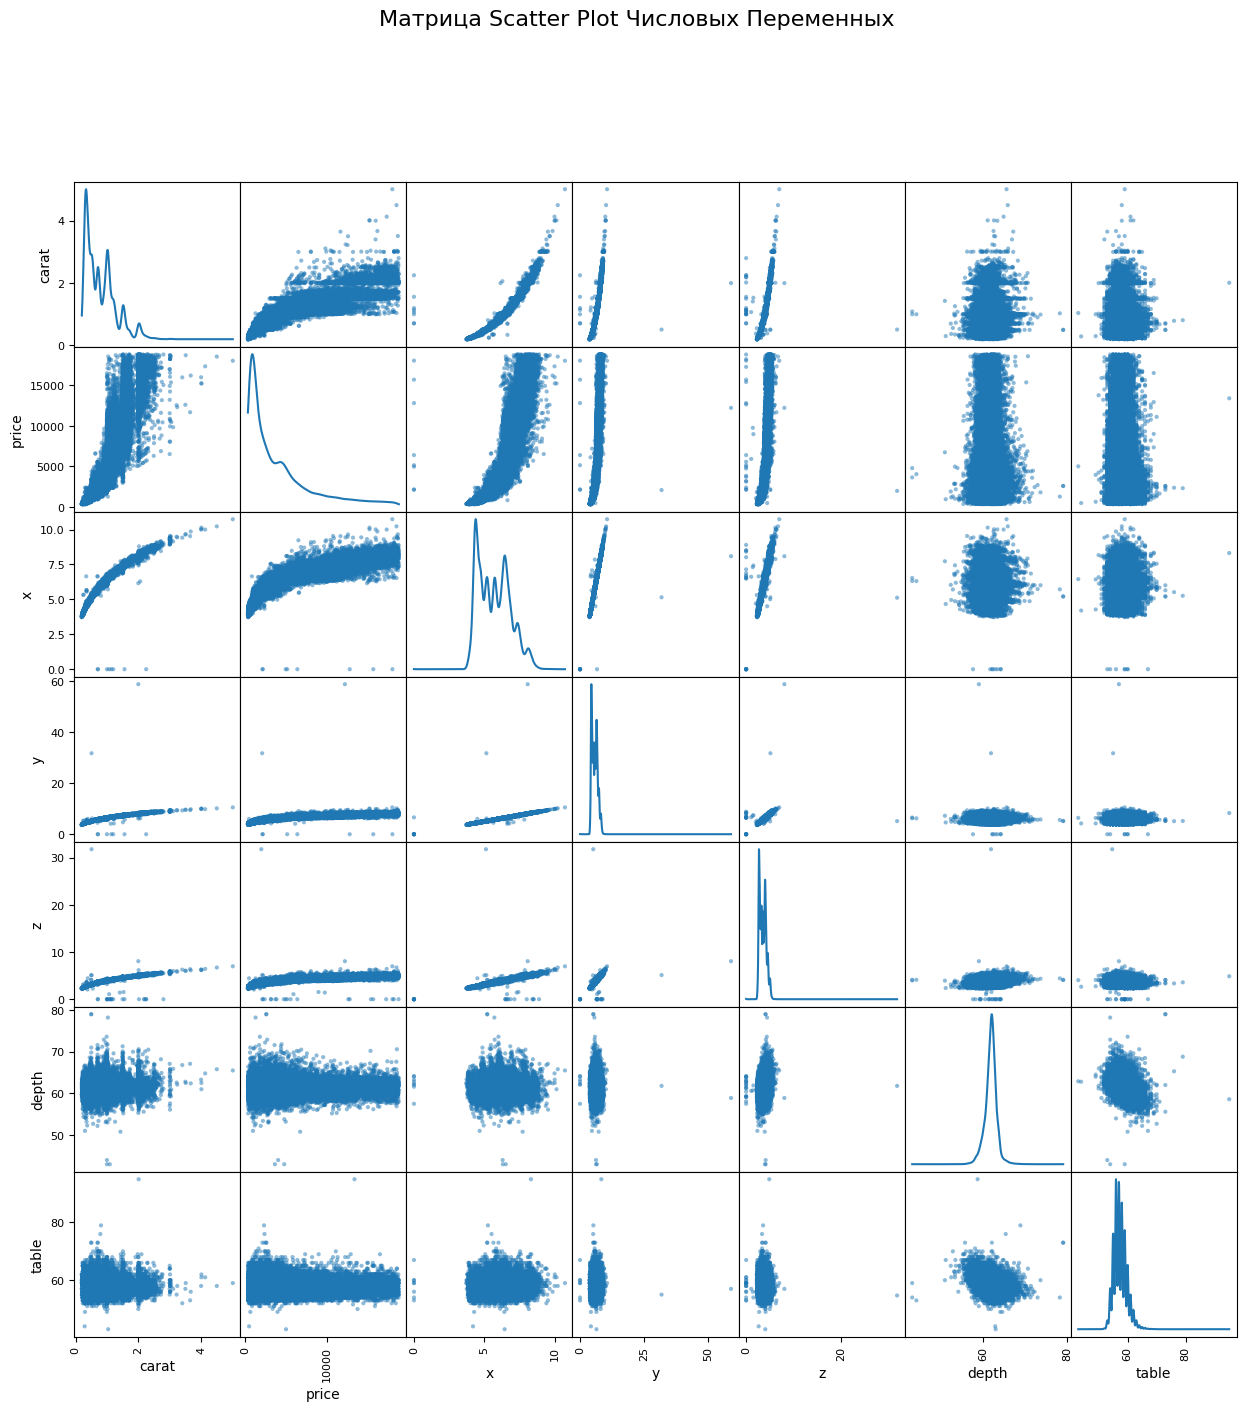

In [5]:
numeric_cols = ['carat', 'price', 'x', 'y', 'z', 'depth', 'table']
plt.figure(figsize=(15, 15))
pd.plotting.scatter_matrix(df[numeric_cols], 
                           figsize=(15, 15),
                           diagonal='kde',
                           alpha=0.5,
                           range_padding=0.1)
plt.suptitle('Матрица Scatter Plot Числовых Переменных', y=0.995, fontsize=16)
plt.show()

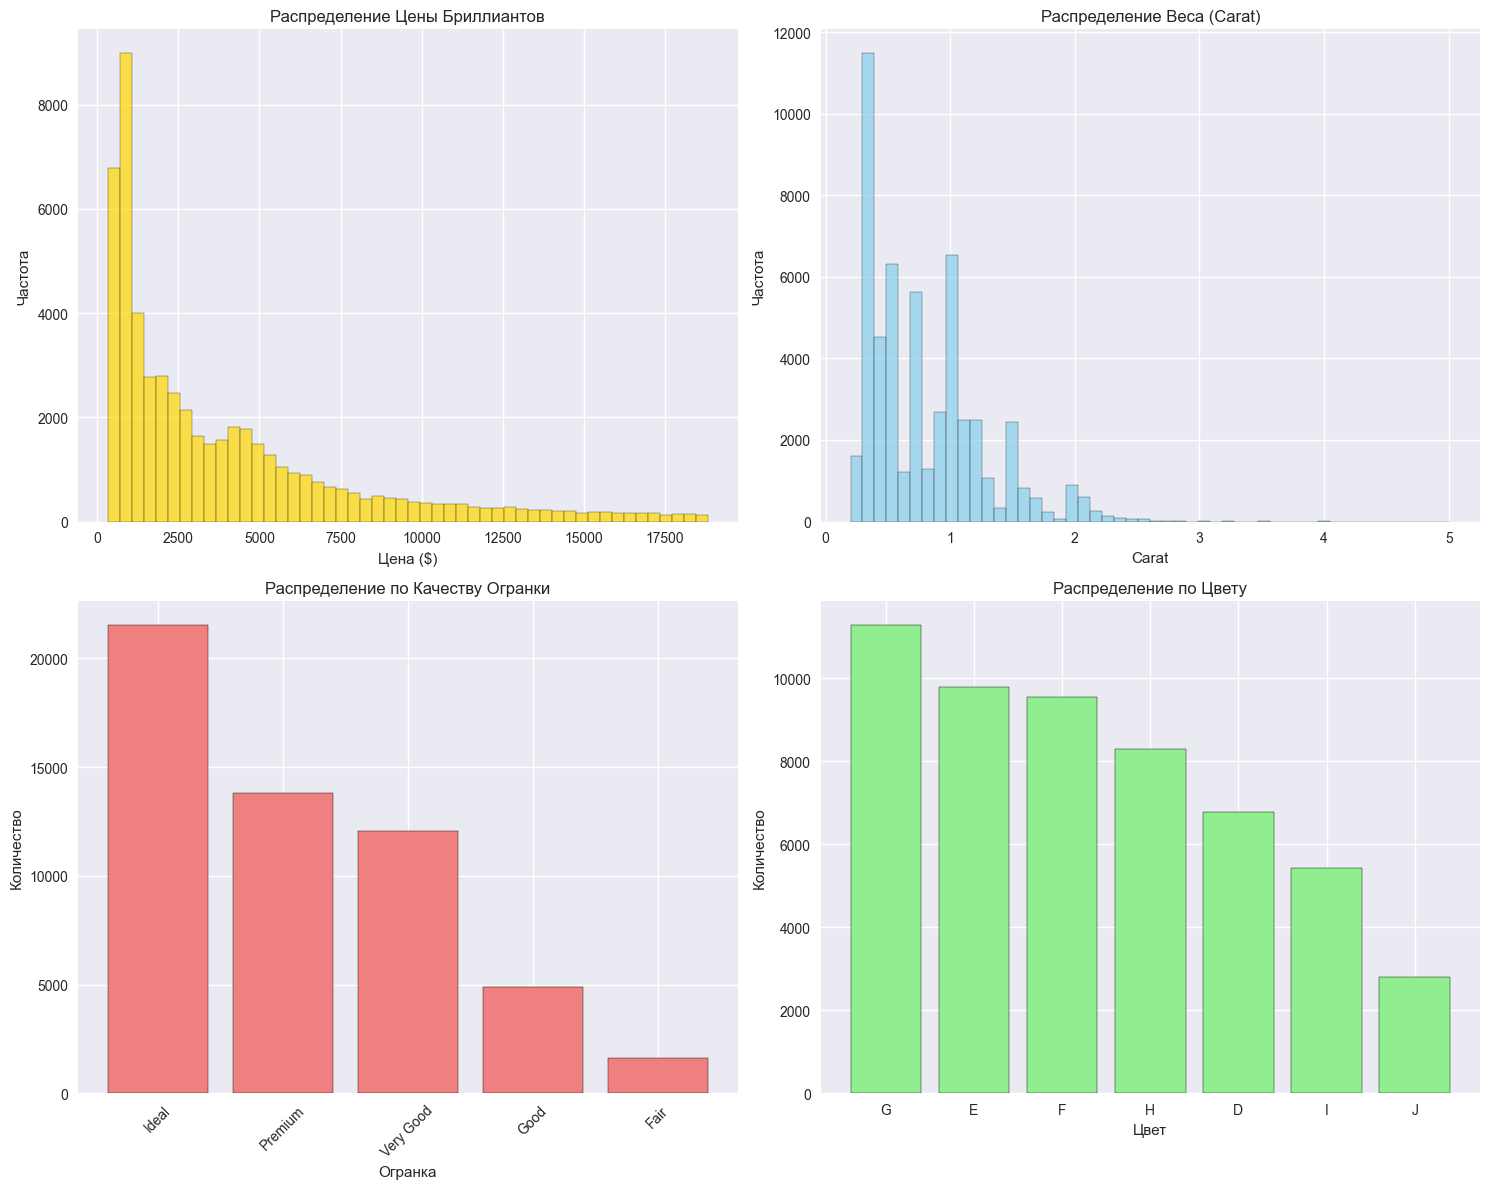

In [6]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Распределение цены
axes[0,0].hist(df['price'], bins=50, alpha=0.7, color='gold', edgecolor='black')
axes[0,0].set_title('Распределение Цены Бриллиантов')
axes[0,0].set_xlabel('Цена ($)')
axes[0,0].set_ylabel('Частота')

# Распределение веса (carat)
axes[0,1].hist(df['carat'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,1].set_title('Распределение Веса (Carat)')
axes[0,1].set_xlabel('Carat')
axes[0,1].set_ylabel('Частота')

# Распределение по категориям огранки
cut_counts = df['cut'].value_counts()
axes[1,0].bar(cut_counts.index, cut_counts.values, color='lightcoral', edgecolor='black')
axes[1,0].set_title('Распределение по Качеству Огранки')
axes[1,0].set_xlabel('Огранка')
axes[1,0].set_ylabel('Количество')
axes[1,0].tick_params(axis='x', rotation=45)

# Распределение по цвету
color_counts = df['color'].value_counts()
axes[1,1].bar(color_counts.index, color_counts.values, color='lightgreen', edgecolor='black')
axes[1,1].set_title('Распределение по Цвету')
axes[1,1].set_xlabel('Цвет')
axes[1,1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Визуально частное распределение цены похоже на экспоненциальное распределение

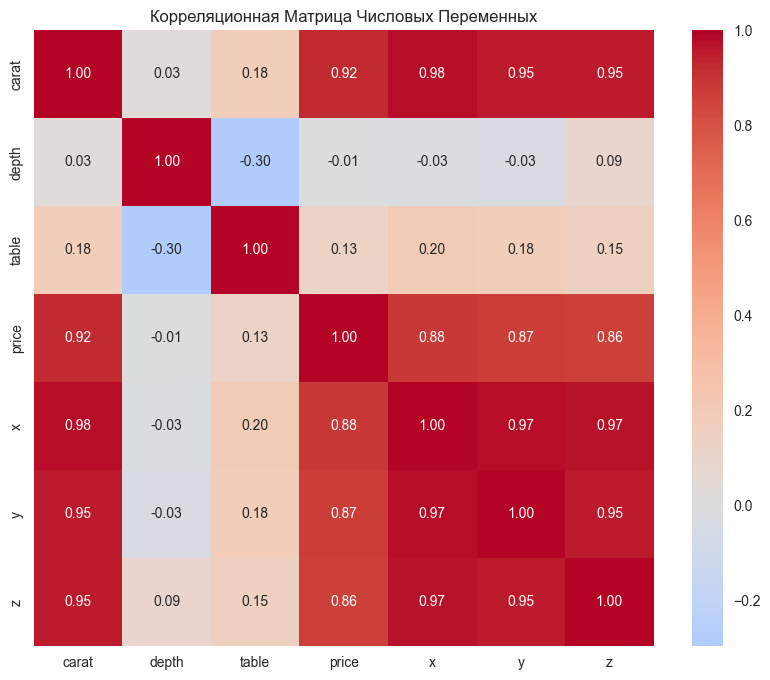

КОРРЕЛЯЦИЯ ЦЕНЫ С ОСНОВНЫМИ ХАРАКТЕРИСТИКАМИ
price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


In [7]:
# Корреляционная матрица числовых переменных
plt.figure(figsize=(10, 8))
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная Матрица Числовых Переменных')
plt.show()

# Корреляция цены с основными характеристиками
print("КОРРЕЛЯЦИЯ ЦЕНЫ С ОСНОВНЫМИ ХАРАКТЕРИСТИКАМИ")
price_corr = df[numeric_cols].corr()['price'].sort_values(ascending=False)
print(price_corr)


Видно, что очень высоко коррелированы между собой значения размеров алмаза и его вес в каратах, что логично. Однако при дальнейшем моделировании возможно стоит это учитывать.

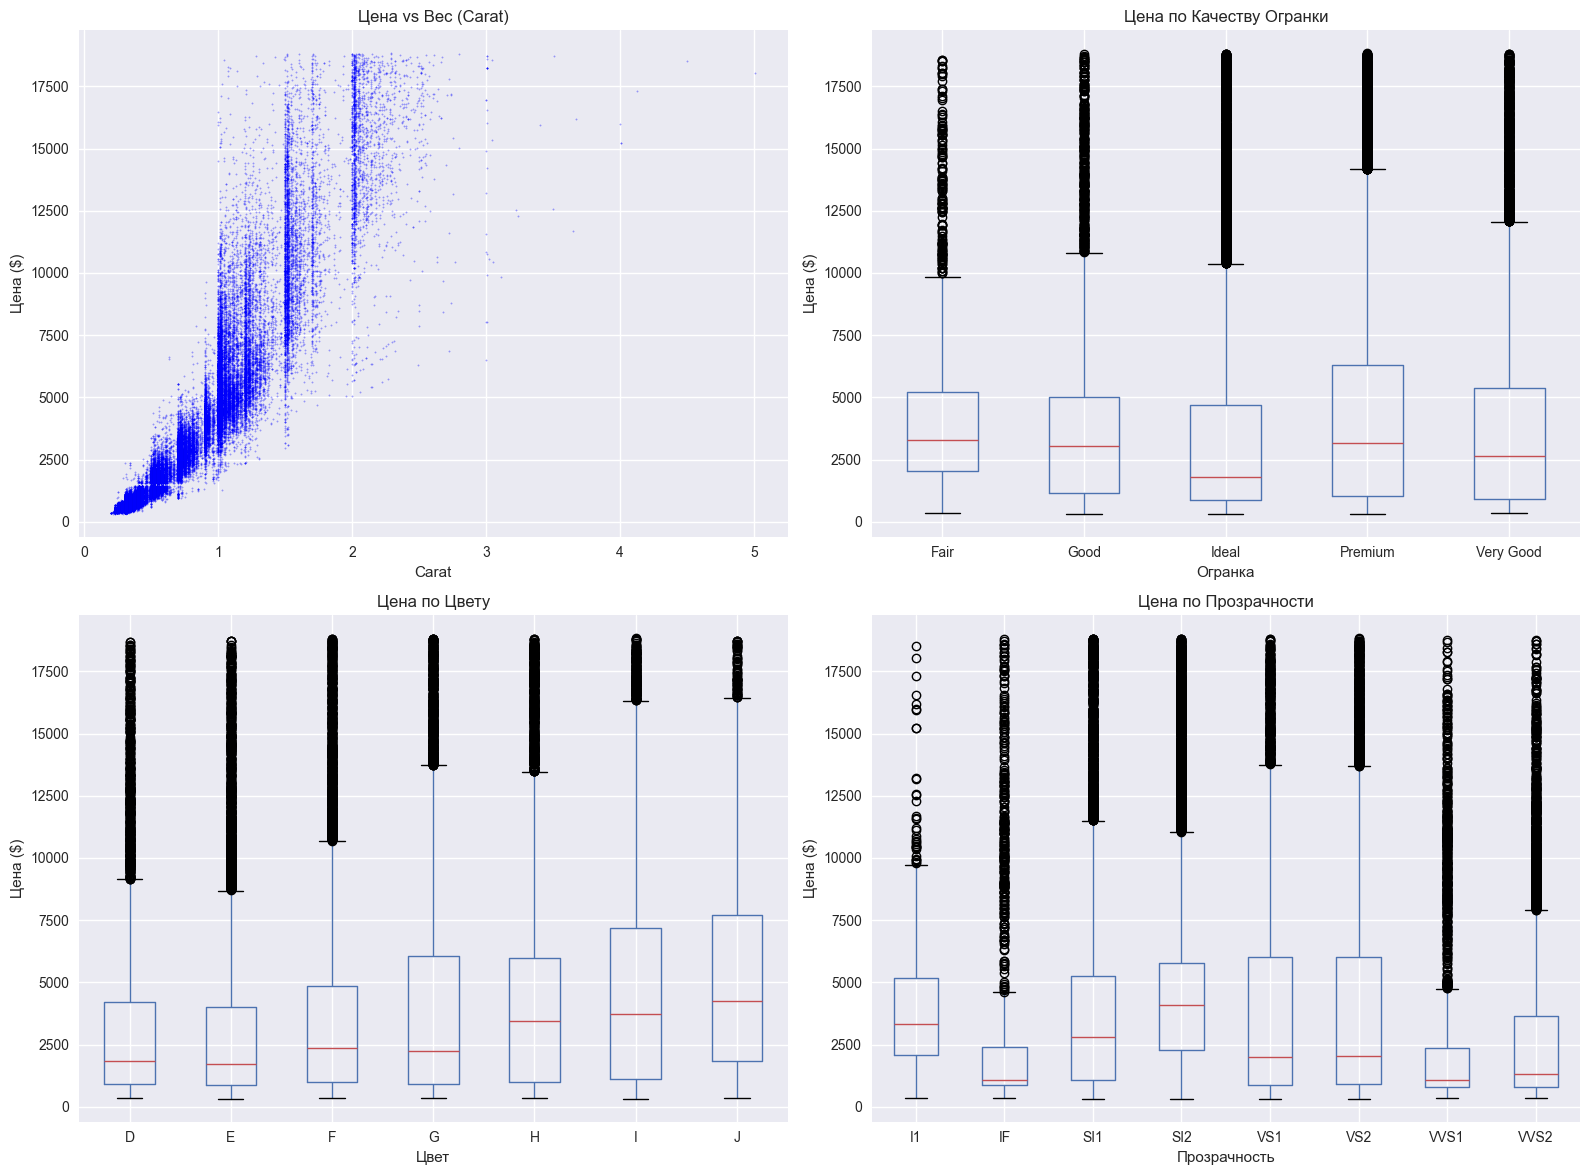

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Цена vs Carat
axes[0,0].scatter(df['carat'], df['price'], alpha=0.3, color='blue', s=1)
axes[0,0].set_title('Цена vs Вес (Carat)')
axes[0,0].set_xlabel('Carat')
axes[0,0].set_ylabel('Цена ($)')

# Цена по категориям огранки
df.boxplot(column='price', by='cut', ax=axes[0,1])
axes[0,1].set_title('Цена по Качеству Огранки')
axes[0,1].set_xlabel('Огранка')
axes[0,1].set_ylabel('Цена ($)')

# Цена по цвету
df.boxplot(column='price', by='color', ax=axes[1,0])
axes[1,0].set_title('Цена по Цвету')
axes[1,0].set_xlabel('Цвет')
axes[1,0].set_ylabel('Цена ($)')

# Цена по прозрачности
df.boxplot(column='price', by='clarity', ax=axes[1,1])
axes[1,1].set_title('Цена по Прозрачности')
axes[1,1].set_xlabel('Прозрачность')
axes[1,1].set_ylabel('Цена ($)')

plt.suptitle('')
plt.tight_layout()
plt.show()


Здесь видно, что цена заметрно отличается для разных цветов, при этом цена алмазов с цветом D (наилучший цвет по описанию в датасете) является наименьшей. Возможно здесь играет роль, что с таким цветом алмазы меньше по размеру. Неожиданным является и то, что ideal огранка, также имеет меньшую стоимость - также может быть связано с размером алмазов (возможно большие алмазы хуже поддаются огранке).


# Гипотезы

Гипотеза 1: Влияние Веса на Цену
H₀: Средняя цена бриллиантов весом ≤1 карат равна средней цене бриллиантов весом >1 карат
H₁: Средняя цена бриллиантов весом >1 карат выше средней цены бриллиантов весом ≤1 карат (Bootstrap-подход к оценке разности средних)

Гипотеза 2: Влияние Качества Огранки на Цену
H₀: Средние цены бриллиантов одинаковы для всех категорий огранки
H₁: Средние цены бриллиантов различаются между категориями огранки (двусторонний ANOVA)

Гипотеза 3: Влияние Цвета на Цену
H₀: Средняя цена бриллиантов цвета D-F (лучшие) равна средней цене бриллиантов цвета G-J (худшие)
H₁: Средняя цена бриллиантов лучшего цвета (D-F) выше средней цены бриллиантов худшего цвета (G-J) (односторонний тест)

Гипотеза 5: Влияние Прозрачности на Цену
H₀: Средние цены бриллиантов с высокой прозрачностью (IF, VVS1, VVS2) равны средним ценам бриллиантов с низкой прозрачностью (SI1, SI2, I1)
H₁: Средние цены различаются между группами прозрачности (двусторонний тест)

## Тест 1: Bootstrap-подход к оценке разности средних

In [13]:
# group_small = df[df['carat'] <= 1]['price']
# group_large = df[df['carat'] > 1]['price']

# print(f"Размер группы ≤1 карат: {len(group_small)}")
# print(f"Размер группы >1 карат: {len(group_large)}")
# print(f"Средняя цена ≤1 карат: ${group_small.mean():.2f}")
# print(f"Средняя цена >1 карат: ${group_large.mean():.2f}")

# # Проверка нормальности (тест Шапиро-Уилка на подвыборке)
# sample_small = group_small.sample(n=5000, random_state=42)
# sample_large = group_large.sample(n=5000, random_state=42)

# shapiro_small = shapiro(sample_small)
# shapiro_large = shapiro(sample_large)

# print(f"\nПроверка нормальности (Shapiro-Wilk):")
# print(f"Группа ≤1 карат: статистика={shapiro_small.statistic:.4f}, p-value={shapiro_small.pvalue:.2e}")
# print(f"Группа >1 карат: статистика={shapiro_large.statistic:.4f}, p-value={shapiro_large.pvalue:.2e}")

# # Проверка равенства дисперсий (тест Левена)
# levene_stat, levene_p = levene(sample_small, sample_large)
# print(f"\nПроверка равенства дисперсий (Levene):")
# print(f"Статистика={levene_stat:.4f}, p-value={levene_p:.4f}")

# # Односторонний t-тест (неравные дисперсии)
# t_stat, t_p = ttest_ind(group_small, group_large, equal_var=False)
# print(f"\nОдносторонний t-тест (Welch's):")
# print(f"t-статистика={t_stat:.4f}, p-value={t_p/2:.4f}")  # Для одностороннего теста

# alpha = 0.05
# if t_p/2 < alpha and t_stat < 0:
#     print(f"Результат: Отвергаем H₀ (p={t_p/2:.4f} < {alpha})")
#     print("Вывод: Бриллианты >1 карата значимо дороже")
# else:
#     print(f"Результат: Не отвергаем H₀ (p={t_p/2:.4f} >= {alpha})")

95% доверительный интервал для (μ_large - μ_small): [6553.00, 6674.32]
Отвергаем H₀: разность средних значимо положительна (бриллианты >1 карата дороже)
Средняя разница: $6613.36


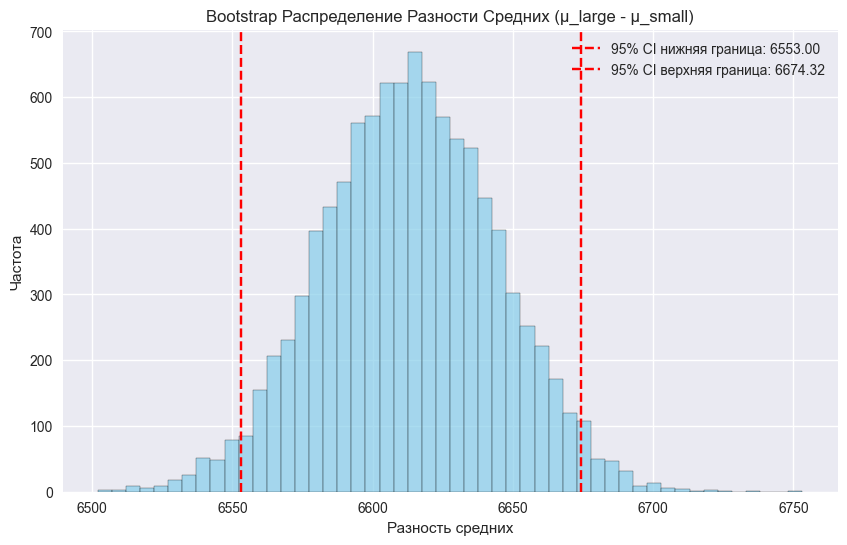

In [11]:
from scipy.stats import bootstrap
group_small = df[df['carat'] <= 1]['price']
group_large = df[df['carat'] > 1]['price']
def statistic(x, y):
    return np.mean(x) - np.mean(y)

# Подготовка данных в виде кортежей
data = (group_large.values, group_small.values)

# Bootstrap (n_resamples=10000 для точности)
res = bootstrap(data, statistic, n_resamples=10000, 
                paired=False, batch=100, random_state=42,
                method='BCa')  # Bias-corrected and accelerated

# Доверительный интервал
ci_low, ci_high = res.confidence_interval
print(f"95% доверительный интервал для (μ_large - μ_small): [{ci_low:.2f}, {ci_high:.2f}]")

# Односторонний тест: проверяем, что интервал не пересекает 0 с положительной стороны
if ci_low > 0:
    print("Отвергаем H₀: разность средних значимо положительна (бриллианты >1 карата дороже)")
    print(f"Средняя разница: ${group_large.mean() - group_small.mean():.2f}")
elif ci_high < 0:
    print("Данные показывают отрицательную разность (≤1 карат дороже >1 карата)")
    print(f"Средняя разница: ${group_large.mean() - group_small.mean():.2f}")
else:
    print("Не отвергаем H₀: интервал разности содержит 0 (нет значимого различия)")

# Визуализация bootstrap распределения
boot_means = res.bootstrap_distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=ci_low, color='red', linestyle='--', label=f'95% CI нижняя граница: {ci_low:.2f}')
plt.axvline(x=ci_high, color='red', linestyle='--', label=f'95% CI верхняя граница: {ci_high:.2f}')
#plt.axvline(x=0, color='black', linestyle='-', label='Нулевая гипотеза (0)')
plt.title('Bootstrap Распределение Разности Средних (μ_large - μ_small)')
plt.xlabel('Разность средних')
plt.ylabel('Частота')
plt.legend()
plt.show()


## Тест 2: ANOVA для влияния огранки на цену

In [10]:
groups_cut = [df[df['cut'] == cut]['price'] for cut in df['cut'].unique()]
cut_labels = df['cut'].unique()

# Проверка нормальности для каждой группы (на подвыборках)
print("Проверка нормальности (Shapiro-Wilk) для каждой группы огранки:")
for i, group in enumerate(groups_cut):
    sample = group.sample(n=min(5000, len(group)), random_state=42)
    shapiro_stat, shapiro_p = shapiro(sample)
    print(f"{cut_labels[i]}: p-value={shapiro_p:.2e}")

# Однофакторный ANOVA
f_stat, f_p = f_oneway(*groups_cut)
print(f"\nANOVA тест:")
print(f"F-статистика={f_stat:.4f}, p-value={f_p:.2e}")

alpha = 0.05
if f_p < alpha:
    print(f"Результат: Отвергаем H₀ (p={f_p:.2e} < {alpha})")
    print("Вывод: Средние цены различаются между категориями огранки")
else:
    print(f"Результат: Не отвергаем H₀ (p={f_p:.2e} >= {alpha})")

# Пост-хок анализ (средние цены по группам)
print("\nСредние цены по категориям огранки:")
for i, group in enumerate(groups_cut):
    print(f"{cut_labels[i]}: ${group.mean():.2f} (n={len(group)})")

Проверка нормальности (Shapiro-Wilk) для каждой группы огранки:
Ideal: p-value=1.02e-65
Premium: p-value=6.06e-58
Good: p-value=1.57e-59
Very Good: p-value=6.31e-60
Fair: p-value=6.60e-40

ANOVA тест:
F-статистика=175.6887, p-value=8.43e-150
Результат: Отвергаем H₀ (p=8.43e-150 < 0.05)
Вывод: Средние цены различаются между категориями огранки

Средние цены по категориям огранки:
Ideal: $3457.54 (n=21551)
Premium: $4584.26 (n=13791)
Good: $3928.86 (n=4906)
Very Good: $3981.76 (n=12082)
Fair: $4358.76 (n=1610)


## Тест 3: Односторонний t-тест для влияния цвета на цену

Размер группы D-F: 26114
Размер группы G-J: 27826
Средняя цена D-F: $3337.76
Средняя цена G-J: $4491.23

Проверка нормальности (Shapiro-Wilk):
Группа D-F: статистика=0.7614, p-value=5.77e-65
Группа G-J: статистика=0.8438, p-value=5.14e-57

Проверка равенства дисперсий (Levene):
Статистика=1102.3953, p-value=0.0000

Односторонний t-тест (Welch):
t-статистика=-34.1264, двусторонний p-value=0.0000, односторонний p-value=0.0000
Результат: Не отвергаем H₀ (p=0.0000 >= 0.05)
Вывод: Статистически значимых доказательств, что D-F дороже G-J, не найдено.


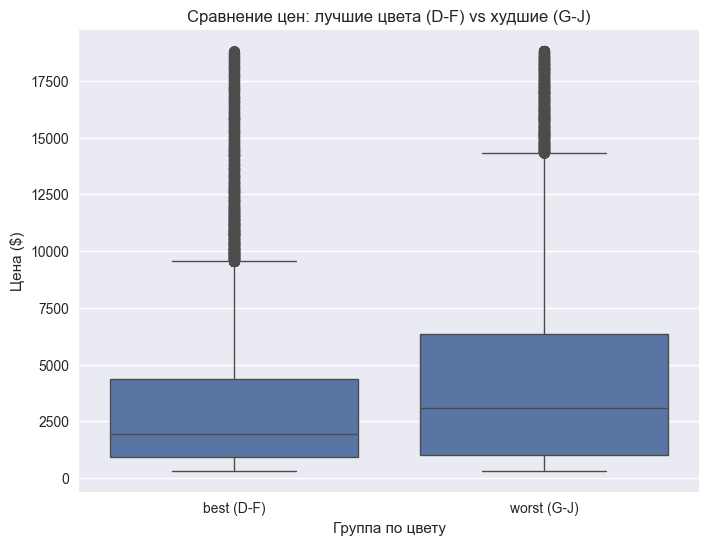

In [10]:
best_colors = ['D', 'E', 'F']
worst_colors = ['G', 'H', 'I', 'J']

group_best = df[df['color'].isin(best_colors)]['price']
group_worst = df[df['color'].isin(worst_colors)]['price']

print(f"Размер группы D-F: {len(group_best)}")
print(f"Размер группы G-J: {len(group_worst)}")
print(f"Средняя цена D-F: ${group_best.mean():.2f}")
print(f"Средняя цена G-J: ${group_worst.mean():.2f}")

# Проверка нормальности (на подвыборках)
sample_best = group_best.sample(n=5000, random_state=42)
sample_worst = group_worst.sample(n=5000, random_state=42)

shapiro_best = shapiro(sample_best)
shapiro_worst = shapiro(sample_worst)

print("\nПроверка нормальности (Shapiro-Wilk):")
print(f"Группа D-F: статистика={shapiro_best.statistic:.4f}, p-value={shapiro_best.pvalue:.2e}")
print(f"Группа G-J: статистика={shapiro_worst.statistic:.4f}, p-value={shapiro_worst.pvalue:.2e}")

# Проверка равенства дисперсий (Levene)
levene_stat, levene_p = levene(group_best, group_worst)
print("\nПроверка равенства дисперсий (Levene):")
print(f"Статистика={levene_stat:.4f}, p-value={levene_p:.4f}")

# Односторонний t-тест (H1: mean_best > mean_worst)
t_stat, t_p_two = ttest_ind(group_best, group_worst, equal_var=False)
t_p_one = t_p_two / 2  # односторонний p-value

print("\nОдносторонний t-тест (Welch):")
print(f"t-статистика={t_stat:.4f}, двусторонний p-value={t_p_two:.4f}, односторонний p-value={t_p_one:.4f}")

alpha = 0.05
if (t_stat > 0.000000001) and (t_p_one < alpha):
    print(f"Результат: Отвергаем H₀ (p={t_p_one:.4f} < {alpha})")
    print("Вывод: Бриллианты с цветом D-F статистически значимо дороже, чем G-J.")
else:
    print(f"Результат: Не отвергаем H₀ (p={t_p_one:.4f} >= {alpha})")
    print("Вывод: Статистически значимых доказательств, что D-F дороже G-J, не найдено.")

plt.figure(figsize=(8, 6))

# Создаём новый столбец с группами цвета
df['color_group'] = df['color'].apply(lambda x: 'best (D-F)' if x in ['D', 'E', 'F'] else 'worst (G-J)')

# Строим боксплот
sns.boxplot(x='color_group', y='price', data=df, order=['best (D-F)', 'worst (G-J)'])
plt.title('Сравнение цен: лучшие цвета (D-F) vs худшие (G-J)')
plt.xlabel('Группа по цвету')
plt.ylabel('Цена ($)')
plt.show()
df.drop('color_group', axis=1, inplace=True)

1. Проверка равенства дисперсий (Levene)
p-value = 0.0000 < 0.05 → дисперсии значимо различаются

Это прямой сигнал использовать t‑тест Уэлча вместо классического t‑теста

Уэлч специально разработал свой вариант для случая неравных дисперсий

2. Проверка нормальности (Shapiro-Wilk)
Оба p-value крайне малы (< 1e-50) → формально нормальность нарушена

НО: при таких огромных выборках (тысячи наблюдений) t‑тест устойчив к нарушению нормальности

Центральная предельная теорема гарантирует, что при n > 30-50 распределение средних приближается к нормальному, даже если исходные данные не нормальны

Практически: t‑тест Уэлча работает корректно на ваших данных

In [14]:
# price_sample = df['price'].sample(n=5000, random_state=42)

# shapiro_stat, shapiro_p = shapiro(price_sample)
# print("Shapiro-Wilk тест (на подвыборке из 5000 наблюдений):")
# print(f"Статистика={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")

# # Тест D’Agostino-Pearson (normaltest) на всех данных или подвыборке
# dag_stat, dag_p = normaltest(price_sample)
# print("\nD’Agostino-Pearson тест (normaltest) на той же подвыборке:")
# print(f"Статистика={dag_stat:.4f}, p-value={dag_p:.4e}")

# alpha = 0.05
# if (shapiro_p < alpha) or (dag_p < alpha):
#     print(f"\nРезультат: Отвергаем H₀ о нормальности распределения цены (минимум один p < {alpha}).")
#     print("Вывод: Распределение цен статистически значимо отклоняется от нормального.")
# else:
#     print(f"\nРезультат: Не отвергаем H₀ о нормальности (все p >= {alpha}).")
#     print("Вывод: Не найдено статистически значимых отклонений от нормальности.")

# # Визуализация распределения и Q-Q график
# from scipy import stats

# plt.figure(figsize=(14, 6))

# plt.subplot(1, 2, 1)
# sns.histplot(df['price'], bins=50, kde=True, color='gold', edgecolor='black')
# plt.title('Гистограмма и KDE для цены бриллиантов')
# plt.xlabel('Цена ($)')
# plt.ylabel('Частота')

# plt.subplot(1, 2, 2)
# stats.probplot(price_sample, dist="norm", plot=plt)
# plt.title('Q-Q график цены (подвыборка)')

# plt.tight_layout()
# plt.show()

## Тест 4: Влияние прозрачности (clarity) на цену

Размер группы высокой прозрачности: 10511
Размер группы низкой прозрачности: 23000
Средняя цена (высокая прозрачность):  $2947.91
Средняя цена (низкая прозрачность):   $4420.22

Проверка нормальности (Shapiro-Wilk):
Высокая прозрачность: p-value=8.81e-72
Низкая прозрачность:  p-value=5.20e-59

Проверка равенства дисперсий (Levene):
Статистика=322.6237, p-value=0.0000

Двусторонний t-тест для разности средних цен по прозрачности:
t-статистика=-32.9831, p-value=6.9137e-233
Результат: Отвергаем H₀ (p=6.9137e-233 < 0.05)
Вывод (t-тест): Средние цены бриллиантов с высокой и низкой прозрачностью статистически различаются.

Z-тест (асимптотический) для разности средних цен по прозрачности:
Z-статистика=-32.0240, двусторонний p-value=5.0604e-225
Результат: Отвергаем H₀ (p=5.0604e-225 < 0.05)
Вывод (z-тест): Разность средних цен по прозрачности статистически значима.


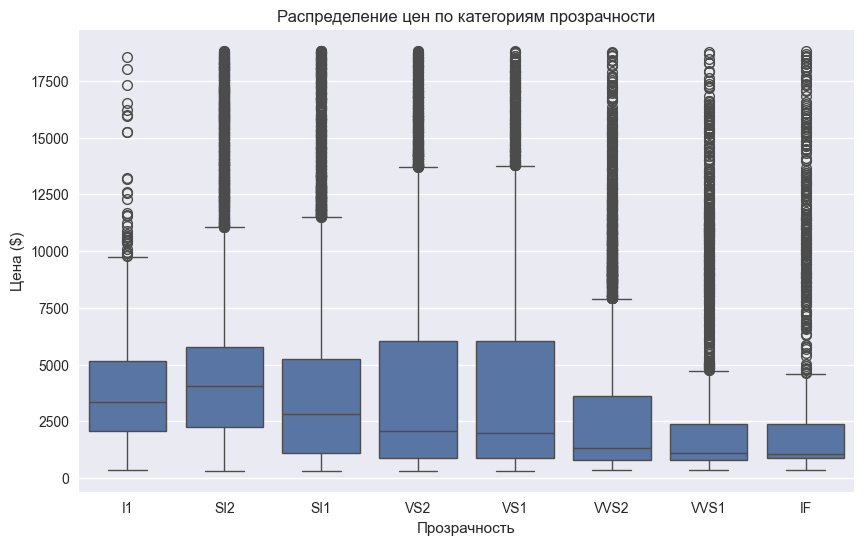

In [14]:
from scipy.stats import norm  # если ещё не импортирован
# Группы по прозрачности:
# высокая (high): IF, VVS1, VVS2
# низкая (low): SI1, SI2, I1
high_clarity = ['IF', 'VVS1', 'VVS2']
low_clarity  = ['SI1', 'SI2', 'I1']

group_high = df[df['clarity'].isin(high_clarity)]['price']
group_low  = df[df['clarity'].isin(low_clarity)]['price']

print(f"Размер группы высокой прозрачности: {len(group_high)}")
print(f"Размер группы низкой прозрачности: {len(group_low)}")
print(f"Средняя цена (высокая прозрачность):  ${group_high.mean():.2f}")
print(f"Средняя цена (низкая прозрачность):   ${group_low.mean():.2f}")

# Проверка нормальности на подвыборках
sample_high = group_high.sample(n=min(5000, len(group_high)), random_state=42)
sample_low  = group_low.sample(n=min(5000, len(group_low)),  random_state=42)

sh_high = shapiro(sample_high)
sh_low  = shapiro(sample_low)

print("\nПроверка нормальности (Shapiro-Wilk):")
print(f"Высокая прозрачность: p-value={sh_high.pvalue:.2e}")
print(f"Низкая прозрачность:  p-value={sh_low.pvalue:.2e}")

# Проверка равенства дисперсий (Levene)
lev_stat, lev_p = levene(group_high, group_low)
print("\nПроверка равенства дисперсий (Levene):")
print(f"Статистика={lev_stat:.4f}, p-value={lev_p:.4f}")

equal_var = (lev_p >= 0.05)

# Двусторонний t-тест (H1: средние цен отличаются)
t_stat, t_p = ttest_ind(group_high, group_low, equal_var=equal_var)
print("\nДвусторонний t-тест для разности средних цен по прозрачности:")
print(f"t-статистика={t_stat:.4f}, p-value={t_p:.4e}")
alpha = 0.05
if t_p < alpha:
    print(f"Результат: Отвергаем H₀ (p={t_p:.4e} < {alpha})")
    print("Вывод (t-тест): Средние цены бриллиантов с высокой и низкой прозрачностью статистически различаются.")
else:
    print(f"Результат: Не отвергаем H₀ (p={t_p:.4e} >= {alpha})")
    print("Вывод (t-тест): Статистически значимых различий средних цен по прозрачности не найдено.")

# Z-тест на разность средних (асимптотический подход при больших n)
n1, n2 = len(group_high), len(group_low)
m1, m2 = group_high.mean(), group_low.mean()
s1, s2 = group_high.std(ddof=1), group_low.std(ddof=1)

# Пул-оценка дисперсии (для z-теста используем оценку "из выборки" как приближение)
sp2 = ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
se = np.sqrt(sp2 * (1/n1 + 1/n2))

z_stat = (m1 - m2) / se
p_z_two = 2 * norm.sf(np.abs(z_stat))

print("\nZ-тест (асимптотический) для разности средних цен по прозрачности:")
print(f"Z-статистика={z_stat:.4f}, двусторонний p-value={p_z_two:.4e}")

if p_z_two < alpha:
    print(f"Результат: Отвергаем H₀ (p={p_z_two:.4e} < {alpha})")
    print("Вывод (z-тест): Разность средних цен по прозрачности статистически значима.")
else:
    print(f"Результат: Не отвергаем H₀ (p={p_z_two:.4e} >= {alpha})")
    print("Вывод (z-тест): Разность средних цен по прозрачности статистически незначима.")

# Визуализация: боксплот по уровню прозрачности
plt.figure(figsize=(10, 6))
sns.boxplot(x='clarity', y='price', data=df,
            order=['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'])
plt.title('Распределение цен по категориям прозрачности')
plt.xlabel('Прозрачность')
plt.ylabel('Цена ($)')
plt.show()

**Выводы по проверки гипотез**

1. По первой гипотезе сравнивались сравнеие цены групп алмазов более и менее 1 грамма по массе, был применен Bootstrap-подход к оценке разности средних.Согласно bootstrap-анализу, 95% доверительный интервал для разности средних цен (μ_>1ct - μ_≤1ct) составил [6553.00, 6674.32], что позволяет отвергнуть нулевую гипотезу и сделать вывод, что разность средних значимо положительна (бриллианты >1 карата дороже).

2. По второй гипотезе сравнивались средние цены по группа огранки (cut) алмазов, для этого проводился однофакторный дисперсионнный анализ (ANOVA, cut ~ price), нулевую гипотезу о равенстве цен по всем группа огранки отвергнуть не получается, так как полученный уровень значимости теста не был меньше заданного альфа, а как следствие - средние цены на брилианты в зависимости от их огранки отличаются.

3. По третьей гипотезе сравнивались средние цены групп алмазов по цвету (color), предварительно все классы цветов были разделены на 2 более глобальные группы - 3 наилучших цвета, и остальные цвета. Аналогично первому тесту были проведены тесты на равенство дисперсий, нормальность распределений и после односторонний т-тест на равенство средних цен между группами цветов алмазов (самых качественных и менее качественных), по полученному уровню значимости теста можно отклонить нулевую гипотезу о равестве средних цен между группами цветов и подтвердить неравенство цен между алмазами с более качественным цветом и менее качественным цветом.

4. Заключительной 4 гипотезой была гипотеза, что средние цены на бриллианты с высокой (IF, VVS1, VVS2) и низкой (SI1, SI2, I1) прозрачностью. Для проверки данной гипотезы были проведены двусторонние t и z тесты. Результат полученного по данным тестам p значения был меньше установленного значения, что говорит о статистической значимости различия средней цены алмаза от его прозрачности. И соответственно изначальная гипотеза была отклонена. Таким образом, при прочих равных параметрах бриллианты с высокой и низкой прозрачностью статистически значимо отличаются по цене. Данный вывод также подтверждается по графику визуально.

Таким образом, был рассмотрен открытый набор данных алмазов на предмет влияния качеств алмазов на их ценовые свойства, а также сформулированы выводы по результатам проверки поставленных гипотез.